In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import json

from utils import (
    TruncatedNormal,
    TruncatedGMM,
    Sinusoidal,
    StepFunction,
    compare_densities,
    plot_density,
)

from methods import (
    BaseEstimator
)

from targeting import cdf_targeting_M_step as targeting_M_step
from targeting import CDFTargetLearner as TargetLearner
from targeting.cdf.learner import cdf_estimand_variance as estimand_variance
from utils.density_computations import generic_compute_cdf_from_density as statistic_from_density

# from targeting import survival_targeting_M_step as targeting_M_step
# from targeting import SurvivalTargetLearner as TargetLearner
# from targeting.survival.learner import survival_estimand_variance as estimand_variance
# from utils.density_computations import generic_compute_survival_from_density as statistic_from_density

# from targeting import moments_targeting_M_step as targeting_M_step
# from targeting import MomentsTargetLearner as TargetLearner
# from targeting.moments.learner import moments_estimand_variance as estimand_variance
# from utils.density_computations import generic_compute_moment_from_density as statistic_from_density

# from targeting import median_targeting_M_step as targeting_M_step
# from targeting import MedianTargetLearner as TargetLearner
# from targeting.median.learner import median_estimand_variance as estimand_variance
# from utils.density_computations import generic_compute_median_from_density as statistic_from_density

In [2]:
RESULT_NAME = "estimation_TruncatedGMM_results_CVXPYEstimator_order_0.json"

# load estimator results from JSON 
with open(f"local/tmp_results/estimation/{RESULT_NAME}", "r") as f:
    estimation_results = json.load(f)

print(f"Loaded estimation results from {RESULT_NAME}.json with items:")
for key, value in estimation_results.items():
    print(f"    - {key}")
    if isinstance(value, dict):
        for sub_key, sub_value in value.items():
            if isinstance(sub_value, (str, float, int)) or len(sub_value) == 0:
                display_val = sub_value
            else:
                display_val = "complex object ..."
            print(f"        - {sub_key}: {display_val}")

Loaded estimation results from estimation_TruncatedGMM_results_CVXPYEstimator_order_0.json.json with items:
    - sampler_setup
        - sampler: TruncatedGMM
        - sampler_params: complex object ...
        - n_samples: 1000
    - estimator_setup
        - estimator: CVXPYEstimator
        - estimator_params: complex object ...
    - results
        - fitted_theta_dict: complex object ...
        - theta_hat: complex object ...
        - data_points: complex object ...
        - grid_points_hal_selected: complex object ...
        - n_selected_knots: 40
        - estimated_density: complex object ...
        - grid_points: complex object ...
        - intercept: -1.0979364564272862
        - hal_coeffs: complex object ...
        - lambda_val_lag: 8.50000300965552
        - optimized_theta_raw: complex object ...
    - fit_params
        - data: complex object ...


In [3]:
# Grab estimator parameters and results
estimator_basis_order = estimation_results["estimator_setup"]["estimator_params"]["basis_order"]
print(f"Estimator basis order: {estimator_basis_order}")
print(f"number of knots: {estimation_results['results']['n_selected_knots']}")

theta_selected_ind = np.concatenate([
    np.arange(0, estimator_basis_order + 1),
    np.array(estimation_results['results']["theta_hat"][estimator_basis_order+1:]).nonzero()[0] + estimator_basis_order + 1
])
print(f"Selected theta indices ({len(theta_selected_ind)}):\n", theta_selected_ind)

theta_selected = np.array(estimation_results['results']["theta_hat"])[theta_selected_ind]
print("Selected theta length:", len(theta_selected))

grid_points_hal_selected = np.array(estimation_results['results']["grid_points_hal_selected"])
print("Selected grid points length:", len(grid_points_hal_selected))

Estimator basis order: 0
number of knots: 40
Selected theta indices (41):
 [  0   1   5  10  22  24  50  73 101 141 146 206 224 235 260 275 293 327
 337 351 360 369 424 434 446 463 464 481 521 538 567 581 628 664 681 692
 714 726 733 754 756]
Selected theta length: 41
Selected grid points length: 40


/var/folders/8v/b1l_n51d2_b4pkp_5kxnxwhh0000gn/T/ipykernel_1904/321587987.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  density_est_plot.show()


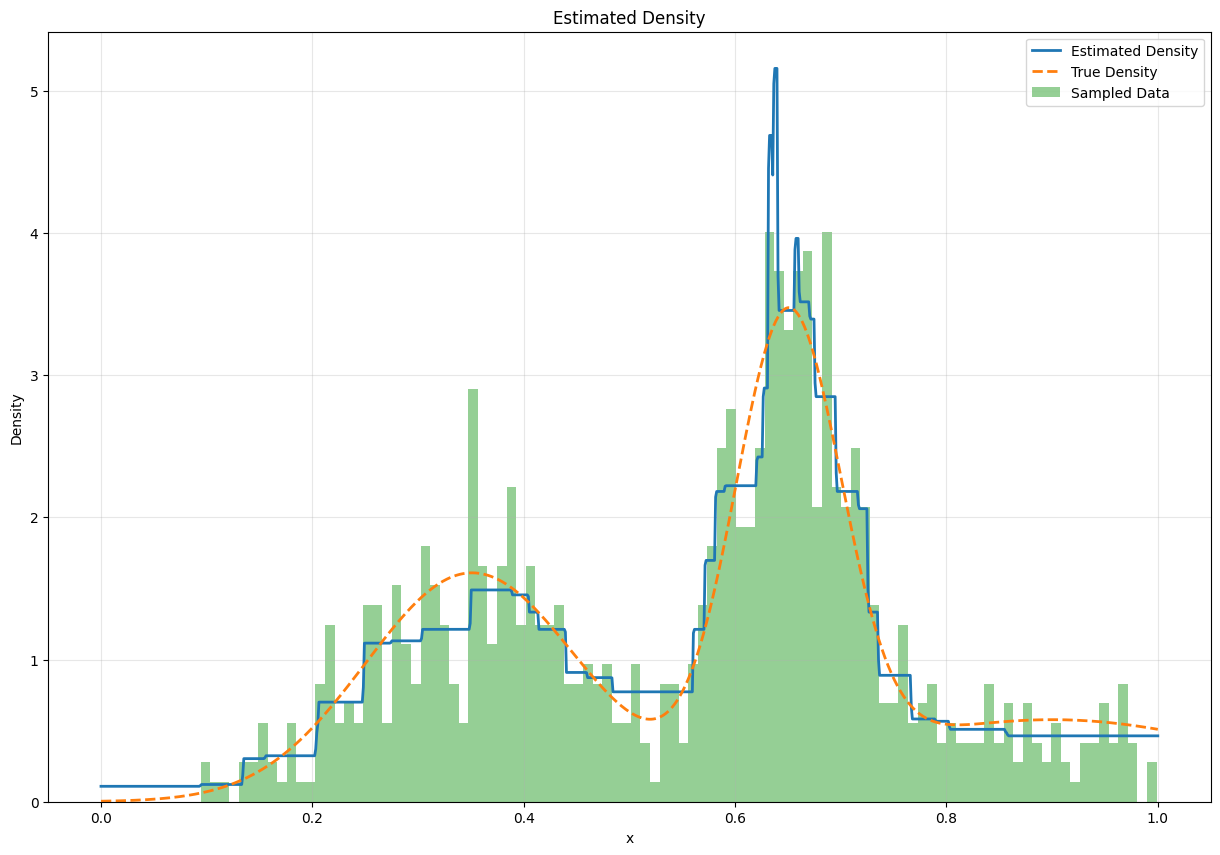

In [4]:
density_est = BaseEstimator.calculate_density_at_points(
    points=np.linspace(0, 1, 1000),
    theta_hat=theta_selected,
    basis_grid_points= grid_points_hal_selected,
    basis_order=estimator_basis_order
)

sampler = TruncatedGMM(**estimation_results["sampler_setup"]["sampler_params"])
assert sampler.__class__.__name__ == estimation_results["sampler_setup"]["sampler"]

# data generated from sampler inside estimator testing
data = pd.DataFrame(estimation_results["fit_params"]["data"])
# data_val = pd.DataFrame(estimation_results["fit_params"]["validation_data"])

density_est_plot = plot_density(
    grid_points=np.linspace(0, 1, 1000),
    true_density=sampler.compute_density(
        np.linspace(0, 1, 1000)
    ),
    estimated_density=density_est,
    title="Estimated Density",
    method_label="Estimated Density",
    show=False,
    figsize=(15, 10)
)

ax = density_est_plot.gca()
ax.hist(
    data["W1"], 
    bins=100, 
    density=True, 
    alpha=0.5, 
    label="Sampled Data"
)

ax.legend()

density_est_plot.show()

In [6]:
# targeting_points = [0.5]
targeting_points = np.linspace(0.01, 0.99, 20)

targeted_fit = targeting_M_step(uncensored_augmented = data,
                                grid_points_hal_selected=grid_points_hal_selected,
                                old_theta = theta_selected,
                                norm_constraint=100,
                                basis_order=estimator_basis_order,
                                # x_moment=3,
                                targeting_points=targeting_points,
                                )

print(targeted_fit.keys())

M-step Design Matrix Calculation time (sec): 0.0073
M-step CVXPY optimize time (sec): 0.4255
dict_keys(['old_theta', 'theta_targeting', 'theta_intercept', 'theta_selected', 'estimated_density', 'grid_midpoints', 'grid_points_hal_selected', 'b_jk', 'b_jk_targeting', 'delta_j', 'grid_eval'])


/var/folders/8v/b1l_n51d2_b4pkp_5kxnxwhh0000gn/T/ipykernel_1904/2988228608.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  density_est_plot.show()


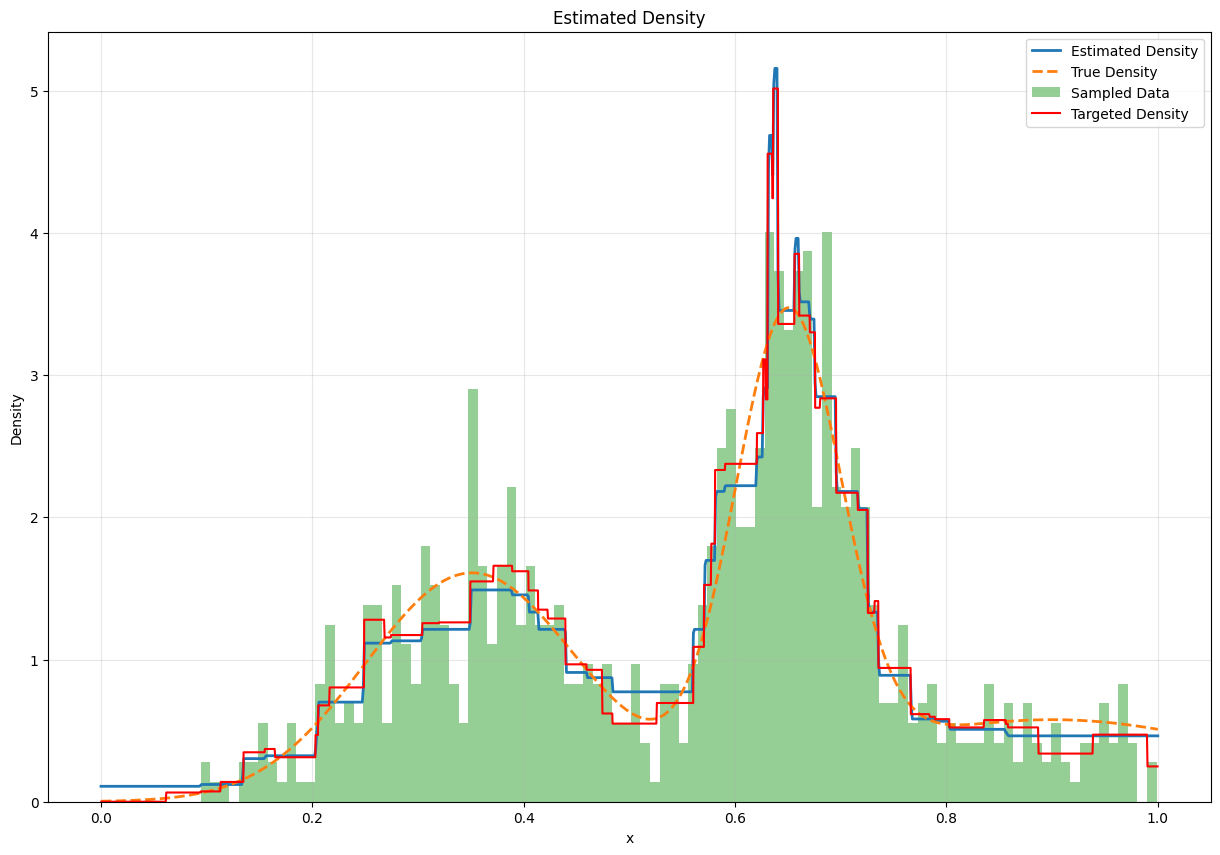

In [7]:
density_est_plot = plot_density(
    grid_points=np.linspace(0, 1, 1000),
    true_density=sampler.compute_density(
        np.linspace(0, 1, 1000)
    ),
    estimated_density=density_est,
    title="Estimated Density",
    method_label="Estimated Density",
    show=False,
    figsize=(15, 10)
)

ax = density_est_plot.gca()
ax.hist(
    data["W1"], 
    bins=100, 
    density=True, 
    alpha=0.5, 
    label="Sampled Data"
)

ax.plot(
    targeted_fit['grid_midpoints'],
    targeted_fit['estimated_density'],
    label="Targeted Density",
    color='red',
)
ax.legend()

density_est_plot.show()

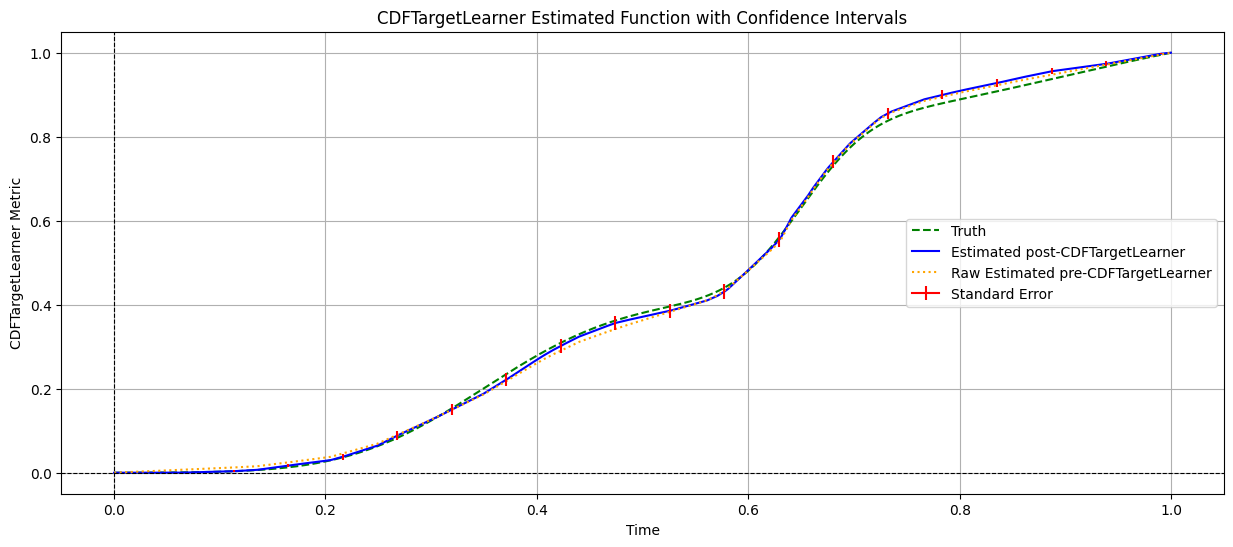

In [9]:
# 1. Compute survival function from density
grid_points = targeted_fit['grid_midpoints']

# stat = statistic_from_density(
stats, grid_points = statistic_from_density(
    grid_points=grid_points,
    density=targeted_fit['estimated_density'],
    # moment_order=3,  # Change this to the desired moment order
)

# true survival function for comparison
# stat_true = statistic_from_density(
stats_true, _ = statistic_from_density(
    grid_points=grid_points,
    density=sampler.compute_density(grid_points),
    # moment_order=3,  # Change this to the desired moment order
)

# raw estimated survival function
raw_density_est = BaseEstimator.calculate_density_at_points(
    points=grid_points,
    theta_hat=theta_selected,
    basis_grid_points= grid_points_hal_selected,
    basis_order=estimator_basis_order
)

# stat_raw = statistic_from_density(
stats_raw, _ = statistic_from_density(
    grid_points=grid_points,
    density=raw_density_est,
    # moment_order=3,  # Change this to the desired moment order
)

# 2. Estimate variances
variances = estimand_variance(
    targeted_fit=targeted_fit,
    uncensored_data=data,
    targeting_points=targeting_points,
    # x_moment=3,
)

# # 3. Get standard errors for confidence intervals
standard_errors = np.sqrt(variances)

# print("Estimated statistic:", stat)
# print("True statistic:", stat_true)
# print("Raw estimated statistic:", stat_raw)
# print("Estimated variances:", variances)
# print("Standard errors for confidence intervals:", standard_errors)


# 4. Plot survival function with confidence intervals
plt.figure(figsize=(15, 6))
plt.plot(grid_points, stats_true, label=f'Truth', color='green', linestyle='--')
plt.plot(grid_points, stats, label=f'Estimated post-{TargetLearner.__name__}', color='blue')
plt.plot(grid_points, stats_raw, label=f'Raw Estimated pre-{TargetLearner.__name__}', color='orange', linestyle=':')
# Plot confidence intervals as bars
for i, point in enumerate(targeting_points):
    # Look up the survival value at the targeting point
    stat_idx = np.searchsorted(grid_points, point)
    stat_i = stats[stat_idx]
    lower_bound = stat_i - 1.96 * standard_errors[i]
    upper_bound = stat_i + 1.96 * standard_errors[i]
    # print(f"Targeting point {i}: {point:.2f}, Survival: {stat_i:.2f}, SE: {standard_errors[i]:.2f}, CI: [{lower_bound:.2f}, {upper_bound:.2f}]")
    plt.errorbar(
        point, 
        stat_i, 
        yerr=standard_errors[i], 
        color='red', 
        label='Standard Error' if i == 0 else ""
    )


plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title(f'{TargetLearner.__name__} Estimated Function with Confidence Intervals')
plt.xlabel('Time')
plt.ylabel(f'{TargetLearner.__name__} Metric')
plt.grid()
plt.legend()
plt.show()